Generating historical revenue data...
Data shape: (24, 4)
Revenue range: $52,484 - $142,876

Train/test split: 19/5

--- Linear Regression ---
R² Score: 0.9920
RMSE: $1,691.90

--- Polynomial Regression (degree 2) ---
R² Score: 0.5921
RMSE: $12,063.69

Linear regression is better (higher R² score)

--- Forecast for next 6 months ---
 Month  Linear_Forecast  Polynomial_Forecast
    25    149080.727200        -7.934666e+05
    26    150576.637936        -1.059868e+06
    27    151996.304975        -1.381911e+06
    28    153415.972014        -1.735849e+06
    29    161880.531582        -1.915134e+06
    30    171830.313351        -2.007292e+06


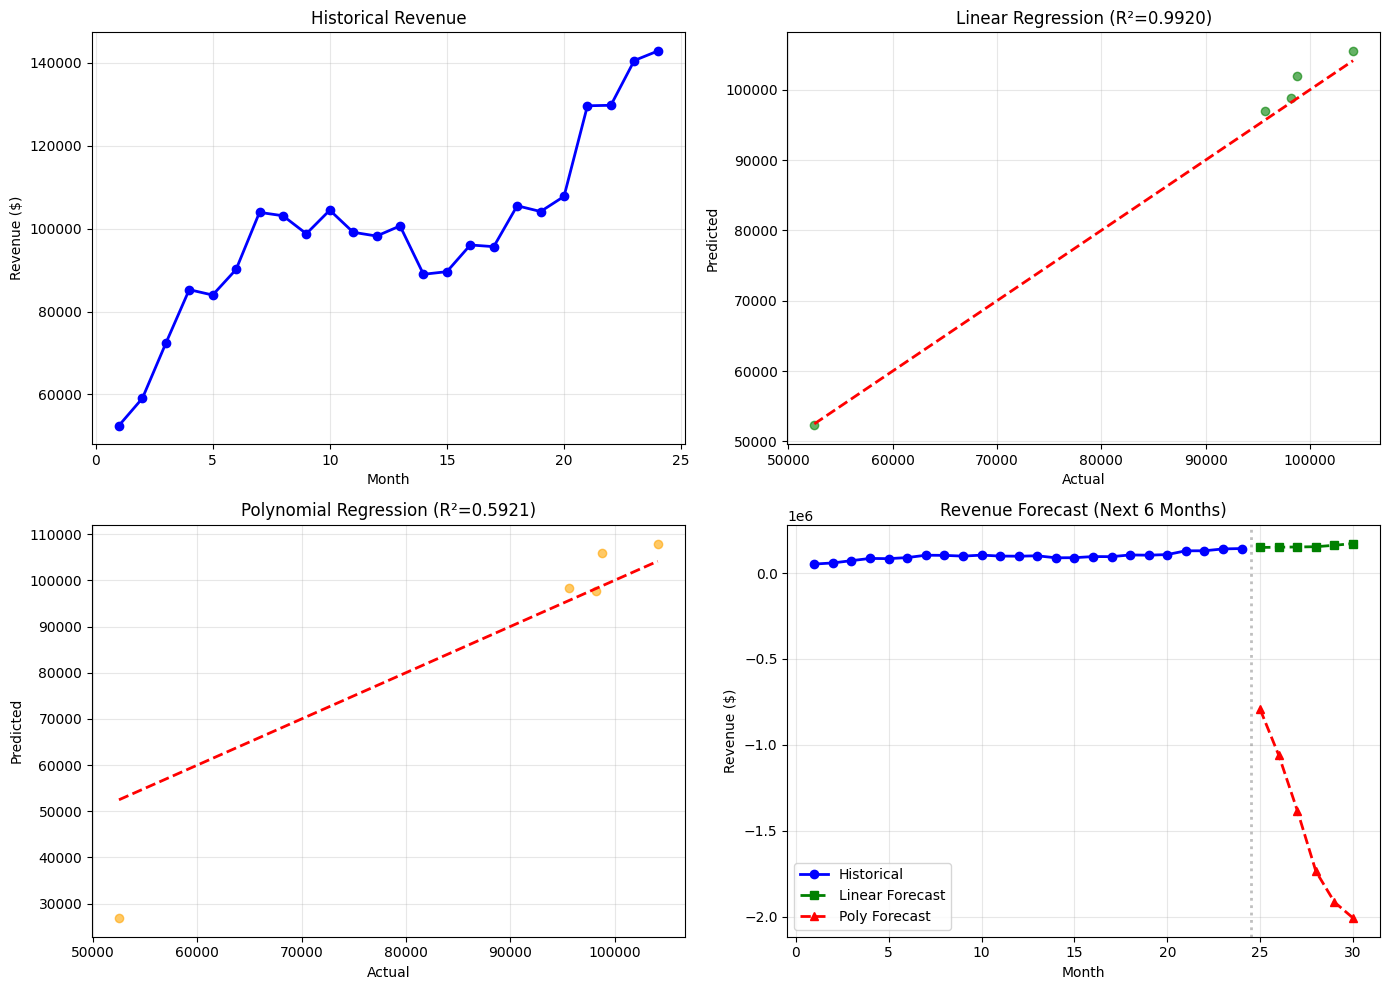


Forecast saved to CSV!


In [1]:
# Revenue Forecasting with Regression
# trying to predict future revenue based on historical data
# hopefully this actually works lol

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Generating historical revenue data...")

# Create some time-series data
np.random.seed(42)
months = 24
dates = pd.date_range('2024-01-01', periods=months, freq='ME')

# Generate somewhat realistic data with trend
base_revenue = np.linspace(50000, 150000, months)
noise = np.random.normal(0, 5000, months)
seasonal = 20000 * np.sin(np.linspace(0, 2*np.pi, months))

data = pd.DataFrame({
    'Month': range(1, months + 1),
    'Temperature': np.sin(np.linspace(0, 2*np.pi, months)) * 15 + 20,
    'Humidity': np.cos(np.linspace(0, 2*np.pi, months)) * 20 + 60,
    'Revenue': base_revenue + seasonal + noise
})

print(f"Data shape: {data.shape}")
print(f"Revenue range: ${data['Revenue'].min():,.0f} - ${data['Revenue'].max():,.0f}")

# Setup for training
X = data[['Month', 'Temperature', 'Humidity']].values
y = data['Revenue'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain/test split: {len(X_train)}/{len(X_test)}")

# Model 1: Linear regression
print("\n--- Linear Regression ---")
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f"R² Score: {lr_r2:.4f}")
print(f"RMSE: ${lr_rmse:,.2f}")

# Model 2: Polynomial regression (degree 2)
print("\n--- Polynomial Regression (degree 2) ---")
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)
poly_pred = poly_lr.predict(X_test_poly)
poly_r2 = r2_score(y_test, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
print(f"R² Score: {poly_r2:.4f}")
print(f"RMSE: ${poly_rmse:,.2f}")

# Which one is better
if lr_r2 > poly_r2:
    print("\nLinear regression is better (higher R² score)")
else:
    print("\nPolynomial regression is better (higher R² score)")

# Make a forecast for the next 6 months
print("\n--- Forecast for next 6 months ---")
future_data = np.array([
    [25, 18, 55],
    [26, 16, 58],
    [27, 14, 60],
    [28, 12, 62],
    [29, 15, 59],
    [30, 19, 56]
])

lr_forecast = lr.predict(future_data)
future_poly = poly.transform(future_data)
poly_forecast = poly_lr.predict(future_poly)

forecast_df = pd.DataFrame({
    'Month': range(25, 31),
    'Linear_Forecast': lr_forecast,
    'Polynomial_Forecast': poly_forecast
})

print(forecast_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Historical revenue
axes[0, 0].plot(data['Month'], data['Revenue'], marker='o', linewidth=2, color='blue')
axes[0, 0].set_title('Historical Revenue')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].grid(True, alpha=0.3)

# Linear regression accuracy
axes[0, 1].scatter(y_test, lr_pred, alpha=0.6, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0, 1].set_title(f'Linear Regression (R²={lr_r2:.4f})')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].grid(True, alpha=0.3)

# Polynomial accuracy
axes[1, 0].scatter(y_test, poly_pred, alpha=0.6, color='orange')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1, 0].set_title(f'Polynomial Regression (R²={poly_r2:.4f})')
axes[1, 0].set_xlabel('Actual')
axes[1, 0].set_ylabel('Predicted')
axes[1, 0].grid(True, alpha=0.3)

# Forecast plot
axes[1, 1].plot(data['Month'], data['Revenue'], 'b-o', label='Historical', linewidth=2, markersize=6)
axes[1, 1].plot(forecast_df['Month'], forecast_df['Linear_Forecast'], 'g--s',
                label='Linear Forecast', linewidth=2, markersize=6)
axes[1, 1].plot(forecast_df['Month'], forecast_df['Polynomial_Forecast'], 'r--^',
                label='Poly Forecast', linewidth=2, markersize=6)
axes[1, 1].axvline(x=24.5, color='gray', linestyle=':', alpha=0.5, linewidth=2)
axes[1, 1].set_title('Revenue Forecast (Next 6 Months)')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Revenue ($)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('revenue_forecast.png', dpi=100)
plt.show()

forecast_df.to_csv('forecast.csv', index=False)
print("\nForecast saved to CSV!")